# Trabajo Integrador 1 - Análisis Exploratorio Básico de una Serie Temporal

## Introducción

In [1]:
from bancomundial import TimeSeriesParser
import matplotlib.pyplot as plt
import scipy
import statsmodels.api as sm

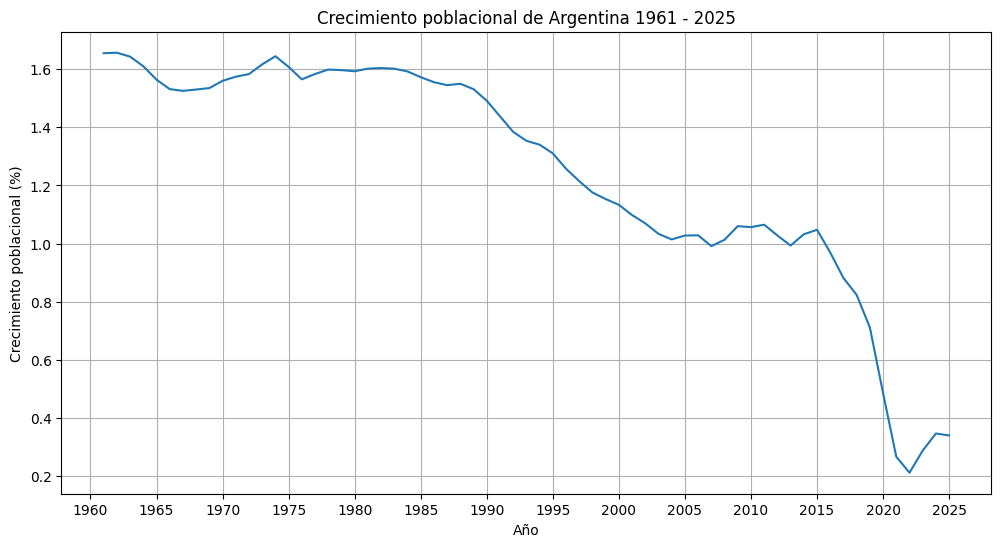

In [2]:

parser = TimeSeriesParser("../data/API_SP.POP.GROW_DS2_es_csv_v2_39933.csv")
series = next(parser.parse("ARG"))
plt.figure(figsize=(12, 6))

plt.plot(series["year"], series["popgrowth"])
plt.title(f"Crecimiento poblacional de Argentina {min(series['year'])} - {max(series['year'])}")
plt.xlabel("Año")
plt.ylabel("Crecimiento poblacional (%)")
plt.xticks([i for i in range(min(series["year"])-1, max(series["year"]) + 1, 5)])
plt.grid()

## Métodos

In [ ]:
series["sma_3"] = series["popgrowth"].rolling(window=3, center=False).mean()
series["var_3"] = series["popgrowth"].rolling(window=3, center=False).var()

series["ewma_3"] = series["popgrowth"].ewm(span=3, adjust=True).mean()
# series["diff_sma_5"] =series["popgrowth"]-series["sma_5"]
# series["diff_ewma_5"] =series["popgrowth"]-series["ewma_5"]


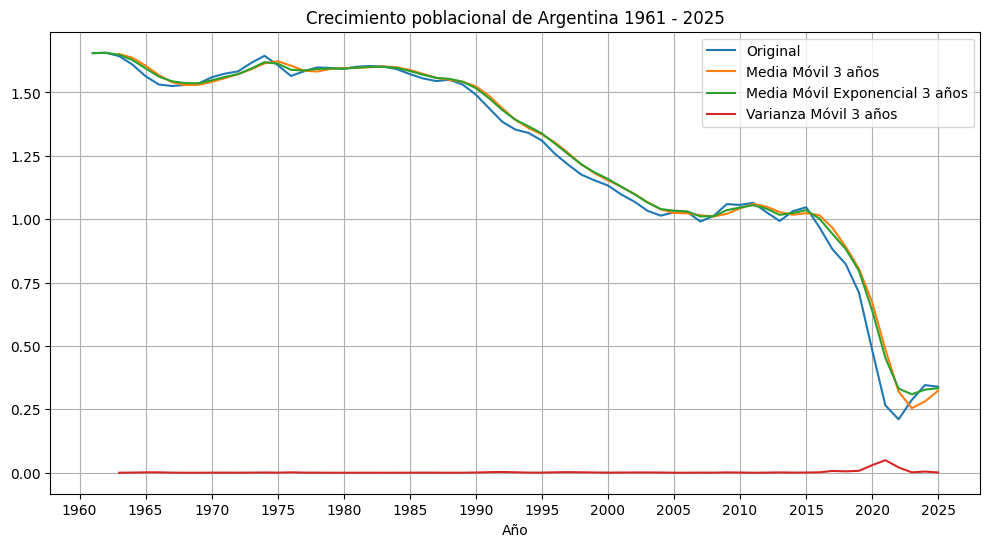

In [4]:
plt.figure(figsize=(12, 6))

plt.plot(series["year"], series["popgrowth"])
plt.plot(series["year"], series["sma_3"])

plt.plot(series["year"], series["ewma_3"])
plt.plot(series["year"], series["var_3"])

# plt.plot(series["year"], series["trend_linear"])
# plt.plot(series["year"], series["detrend_linear"])

plt.legend(["Original", "Media Móvil 3 años",  "Media Móvil Exponencial 3 años",
            "Varianza Móvil 3 años",
            # "Tendencia Lineal",
            # "Ruido"
            ])
plt.title(f"Crecimiento poblacional de Argentina {min(series['year'])} - {max(series['year'])}")
plt.xlabel("Año")
plt.xticks([i for i in range(min(series["year"])-1, max(series["year"]) + 1, 5)])
plt.grid()

### Transformación ln



In [8]:
import numpy as np
series["log_popgrowth"] = np.log(series["popgrowth"])
series["detrend_linear_log"] = scipy.signal.detrend(series["log_popgrowth"], type="linear")
series["trend_linear_log"] = series["log_popgrowth"] - series["detrend_linear_log"]
series["detrend_constant_log"] = scipy.signal.detrend(series["log_popgrowth"], type="constant")
series["trend_constant_log"] = series["log_popgrowth"] - series["detrend_constant_log"]

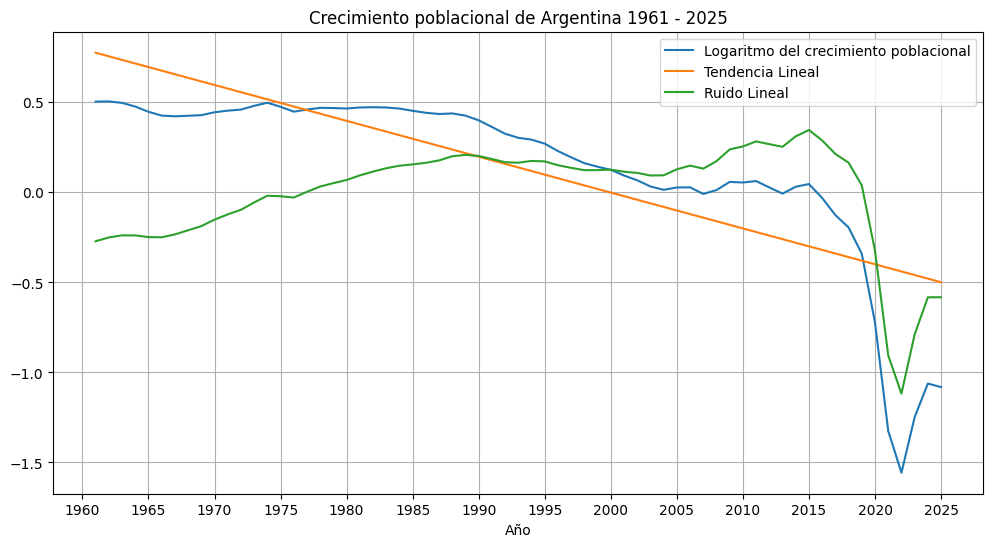

In [11]:
plt.figure(figsize=(12, 6))
plt.plot(series["year"], series["log_popgrowth"])
plt.plot(series["year"], series["trend_linear_log"])
plt.plot(series["year"], series["detrend_linear_log"])
plt.legend(["Logaritmo del crecimiento poblacional", "Tendencia Lineal", "Ruido Lineal"])
plt.title(f"Crecimiento poblacional de Argentina {min(series['year'])} - {max(series['year'])}")
plt.xlabel("Año")
plt.xticks([i for i in range(min(series["year"])-1, max(series["year"]) + 1, 5)])
plt.grid()

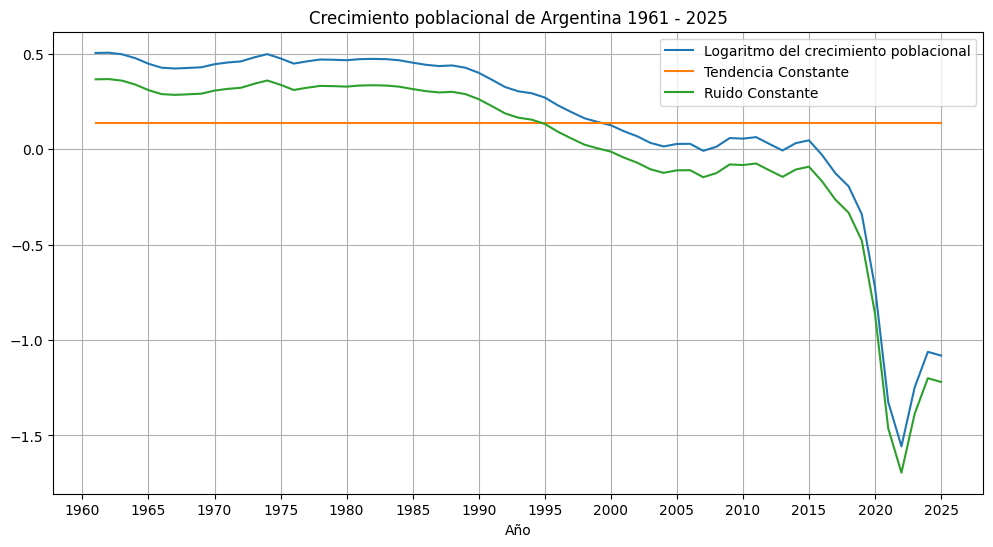

In [10]:
plt.figure(figsize=(12, 6))
plt.plot(series["year"], series["log_popgrowth"])
plt.plot(series["year"], series["trend_constant_log"])
plt.plot(series["year"], series["detrend_constant_log"])
plt.legend(["Logaritmo del crecimiento poblacional", "Tendencia Constante", "Ruido Constante"])
plt.title(f"Crecimiento poblacional de Argentina {min(series['year'])} - {max(series['year'])}")
plt.xlabel("Año")
plt.xticks([i for i in range(min(series["year"])-1, max(series["year"]) + 1, 5)])
plt.grid()

In [12]:
ruido = np.exp(series["detrend_linear_log"])

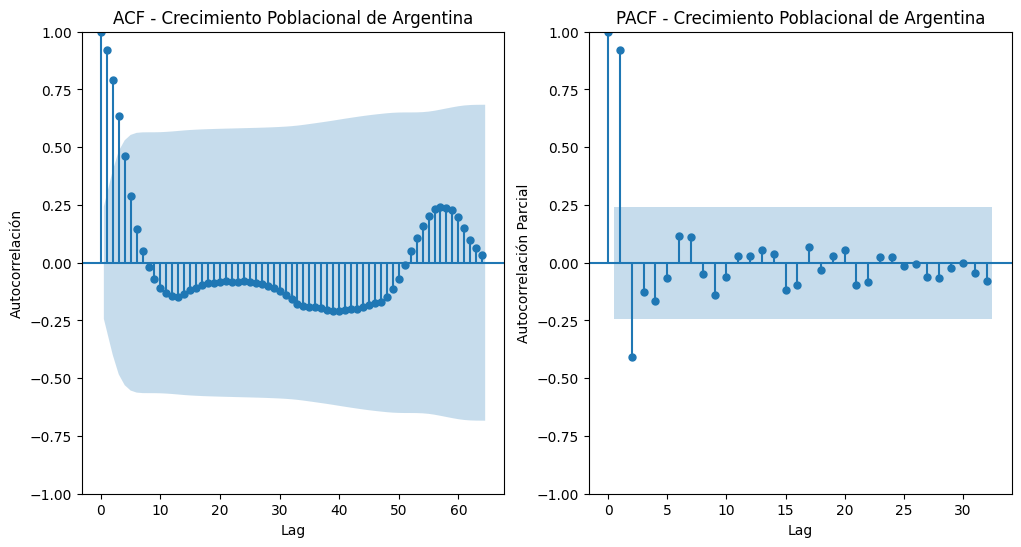

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

sm.graphics.tsa.plot_acf(ruido, lags=len(ruido)-1, ax=axes[0])
sm.graphics.tsa.plot_pacf(ruido, lags=32, ax=axes[1])
axes[0].set_title("ACF - Crecimiento Poblacional de Argentina")
axes[0].set_xlabel("Lag")
axes[0].set_ylabel("Autocorrelación")
axes[1].set_title("PACF - Crecimiento Poblacional de Argentina")
axes[1].set_xlabel("Lag")
axes[1].set_ylabel("Autocorrelación Parcial")
plt.show()

## Resultados e Interpretación